# Comparison of `mu_prior` for Burgers (LB/UB)

Ce notebook reprend le script `tutorials/examples/boed/compare_mu_prior_burgers.py` dans un format plus pédagogique et ordonné.

Pipeline:
1. Définir les paramètres et les prioris
2. Estimer `l_theta`, `H_theta`, `Sigma_Y`, `Sigma_signal`
3. Construire la trajectoire gloutonne de capteurs (critère LB)
4. Comparer LB/UB selon `lambda` et `mu_prior`


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
import scipy.linalg as sla


def find_repo_root(start: Path) -> Path:
    """Trouve le dossier racine contenant le package `boed`."""
    for candidate in [start, *start.parents]:
        if (candidate / "boed").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from boed.core import make_u0
from boed.core.noise import ColoredNoise
from boed.pde.burgers import Burgers_CN
from boed.priors.gp_priors import GaussianProcessPrior
from boed.priors.kernels import Matern32
from boed.utils.observation import build_selection_matrices

SEED = 42
np.random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"SEED = {SEED}")


REPO_ROOT = /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks
SEED = 42


## 1) Paramètres de l'expérience

Vous pouvez modifier cette cellule pour tester d'autres résolutions, budgets, valeurs de `lambda` ou prioris moyens.

In [ ]:
# ------------------------------
# Paramètres physiques / modèle
# ------------------------------
N = 100
dt = 0.001
n_steps = 100
diffusivity = 0.02
sigma = 0.05

# ------------------------------
# Paramètres Monte Carlo
# ------------------------------
n_samples_lh = 120
n_samples_sigma_y = 800

# Valeurs de lambda à comparer
lambda_values = np.linspace(0.0, 1.0, 2).tolist()  # ex: [0.0, 0.25, 0.5, 0.75, 1.0]
lambda_values = list(dict.fromkeys([float(v) for v in lambda_values]))

# Budgets de capteurs
sensor_budgets = [b for b in [5, 10, 15] if b <= N]
if not sensor_budgets:
    raise ValueError(f"N={N} est trop petit pour les budgets sélectionnés.")

# Dossier de sortie des figures
output_dir = REPO_ROOT / "boed/results_mu_prior_burgers"
output_dir.mkdir(parents=True, exist_ok=True)

# Configurations de moyennes de prior (activez/désactivez selon besoin)
mu_configs = [
    ("alpha=0", np.zeros(N), "mu0"),
    # ("alpha=+4", np.ones(N) * 4.0, "mu_pos4"),
    # ("alpha=-4", -np.ones(N) * 4.0, "mu_neg4"),
]

print("lambda_values:", lambda_values)
print("sensor_budgets:", sensor_budgets)
print("output_dir:", output_dir)


lambda_values: [0.0, 1.0]
sensor_budgets: [5, 10, 15, 20, 25]
output_dir: /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks/boed/results_mu_prior_burgers


## 2) Fonctions utilitaires

On reprend les estimateurs et critères utilisés dans le script original.

In [ ]:
def make_prior(kernel_obj, nx, mu):
    return GaussianProcessPrior(kernel_obj, nx=nx, mu=mu)


def make_forward_model(pde_model, n_steps_local):
    """Forward map G : theta -> u(T)."""

    def G(theta):
        u_final = pde_model.evolve(u0=theta, n_steps=n_steps_local)
        return u_final[-1, :]

    return G


def jacobian_fd(G_fun, theta, h=None):
    """Jacobian centré par différences finies."""
    d = theta.shape[0]
    if h is None:
        h = np.finfo(float).eps ** (1 / 3) * (la.norm(theta) + 1e-8)

    m = G_fun(theta).shape[0]
    J = np.zeros((m, d))

    for j in range(d):
        e_j = np.zeros(d)
        e_j[j] = 1.0
        J[:, j] = (G_fun(theta + h * e_j) - G_fun(theta - h * e_j)) / (2 * h)

    return J


def estimate_H_and_l_consistent(G_fun, prior, Sigma_obs_mat, n_samples):
    """Estimateur MC cohérent de l_theta et H_theta."""
    Sigma_inv = la.inv(Sigma_obs_mat)
    Sigma_inv_sqrt = sla.sqrtm(Sigma_inv)

    theta_samples = np.random.multivariate_normal(
        mean=prior.mu, cov=prior.Sigma, size=n_samples
    )
    J_all = np.array([jacobian_fd(G_fun, theta) for theta in theta_samples])

    # l_theta = E[J]^T
    l_theta = J_all.mean(axis=0).T

    # X_k = J_k^T Sigma^{-1/2}
    X_all = np.einsum("kmd,mn->kdn", J_all, Sigma_inv_sqrt)
    X_mean = X_all.mean(axis=0)
    X_centered = X_all - X_mean

    # Covariance sur les dimensions (sample, observation)
    H_theta = np.einsum("kdm,knm->dn", X_centered, X_centered) / (n_samples - 1)
    return l_theta, H_theta


def estimate_Sigma_Y(G_fun, prior, Sigma_obs_mat, n_samples):
    """Estimateur MC de Sigma_Y = Sigma_obs + Cov[G(theta)]."""
    theta_samples = np.random.multivariate_normal(
        mean=prior.mu, cov=prior.Sigma, size=n_samples
    )
    U = np.array([G_fun(theta) for theta in theta_samples])
    U = U[np.all(np.isfinite(U), axis=1)]
    if U.shape[0] < 2:
        raise RuntimeError("Pas assez d'échantillons finis pour estimer Sigma_Y.")
    return Sigma_obs_mat + np.cov(U, rowvar=False, bias=False)


def compute_Sigma_signal(l_theta, H_theta, prior, Sigma_obs_mat):
    """Sigma_signal = Sigma_obs + l^T (Sigma_prior^{-1} + H)^{-1} l."""
    A = la.inv(prior.Sigma) + H_theta
    X = la.solve(A, l_theta)
    return Sigma_obs_mat + l_theta.T @ X


def delta_UB(Sigma_signal, Sigma_obs_mat, W):
    """Estimateur de type upper bound (UB)."""

    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_obs_mat.shape[0])
    return 0.5 * (
        log_ratio(Sigma_signal, Sigma_obs_mat, W)
        - log_ratio(Sigma_signal, Sigma_obs_mat, eye)
    )


def delta_LB(Sigma_Y, Sigma_obs_mat, W):
    """Estimateur de type lower bound (LB)."""

    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_obs_mat.shape[0])
    return 0.5 * (
        log_ratio(Sigma_Y, Sigma_obs_mat, W)
        - log_ratio(Sigma_Y, Sigma_obs_mat, eye)
    )


def greedy_maximize_LB(Sigma_Y, Sigma_obs_mat, n_sensors):
    """Sous-ensemble glouton maximisant le proxy LB."""
    n_obs = Sigma_Y.shape[0]
    selected = []
    remaining = list(range(n_obs))

    for _ in range(n_sensors):
        best_idx = None
        best_score = -np.inf

        for idx in remaining:
            S = selected + [idx]
            ix = np.ix_(S, S)
            score = la.slogdet(Sigma_Y[ix])[1] - la.slogdet(Sigma_obs_mat[ix])[1]
            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(best_idx)
        remaining.remove(best_idx)

    return np.array(selected)


## 3) Construction du problème (grille, prior, bruit)

In [7]:
x_grid = np.linspace(0.0, 1.0, N + 2)[1:-1]
u0_true = make_u0(x_grid, "gaussian", center=0.25, width=0.07, amplitude=1.5)

kernel = Matern32(length_scale=0.1, sigma=1.0)
noise = ColoredNoise(sigma_noise=sigma, correlation_length=20.3)
Sigma_obs = noise.get_covariance(N)

print("x_grid shape:", x_grid.shape)
print("Sigma_obs shape:", Sigma_obs.shape)


x_grid shape: (100,)
Sigma_obs shape: (100, 100)


## 4) Boucle principale (mu_prior x lambda)

Cette cellule calcule LB/UB pour chaque combinaison, ainsi que la trajectoire gloutonne de capteurs.

In [8]:
results = {}

for name, mu_vec, mu_slug in mu_configs:
    print("\n" + "=" * 72)
    print(f"Running case: {name}")

    prior = make_prior(kernel, N, mu_vec)
    results[name] = {"mu": mu_vec, "mu_slug": mu_slug, "by_lambda": {}}

    for lambda_ in lambda_values:
        print(f"  -> lambda={lambda_:g}")
        model = Burgers_CN(N=N, dt=dt, diffusivity=diffusivity, lambda_=lambda_)
        G = make_forward_model(model, n_steps)

        l_theta, H_theta = estimate_H_and_l_consistent(
            G_fun=G,
            prior=prior,
            Sigma_obs_mat=Sigma_obs,
            n_samples=n_samples_lh,
        )
        Sigma_signal = compute_Sigma_signal(l_theta, H_theta, prior, Sigma_obs)

        Sigma_Y = estimate_Sigma_Y(
            G_fun=G,
            prior=prior,
            Sigma_obs_mat=Sigma_obs,
            n_samples=n_samples_sigma_y,
        )

        max_budget = max(sensor_budgets)
        indices_path = greedy_maximize_LB(
            Sigma_Y=Sigma_Y,
            Sigma_obs_mat=Sigma_obs,
            n_sensors=max_budget,
        )

        lb_vals = []
        ub_vals = []

        for budget in sensor_budgets:
            indices = indices_path[:budget]
            W, _ = build_selection_matrices(N, indices)

            lb = delta_LB(Sigma_Y, Sigma_obs, W)
            ub = delta_UB(Sigma_signal, Sigma_obs, W)

            lb_vals.append(lb)
            ub_vals.append(ub)

        lb_arr = np.array(lb_vals)
        ub_arr = np.array(ub_vals)
        gap_arr = ub_arr - lb_arr

        results[name]["by_lambda"][lambda_] = {
            "l_theta": l_theta,
            "H_theta": H_theta,
            "Sigma_Y": Sigma_Y,
            "Sigma_signal": Sigma_signal,
            "indices_path": indices_path,
            "LB": lb_arr,
            "UB": ub_arr,
            "GAP": gap_arr,
        }

        print(
            f"     final budget {sensor_budgets[-1]} | "
            f"LB={lb_arr[-1]:.3f}, UB={ub_arr[-1]:.3f}, gap={gap_arr[-1]:.3f}"
        )



Running case: alpha=0
  -> lambda=0
     final budget 25 | LB=-0.548, UB=-0.545, gap=0.003
  -> lambda=1
     final budget 25 | LB=-8.802, UB=-0.190, gap=8.612


## 5) Figure LB/UB par `mu_prior` et `lambda`

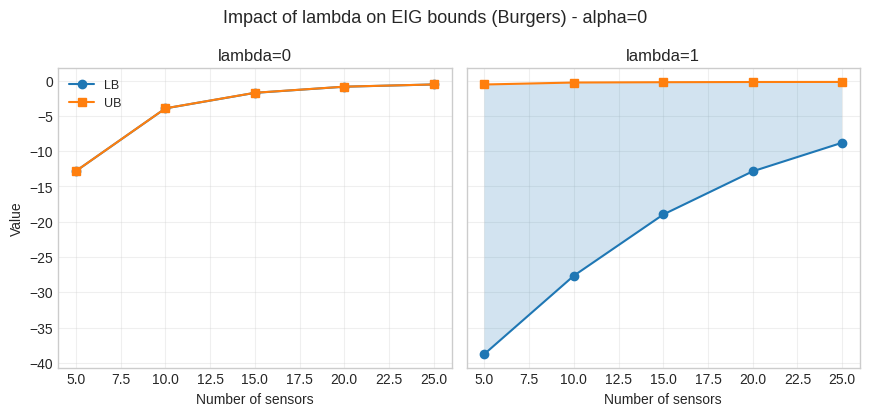

In [9]:
saved_files = []
n_lambda = len(lambda_values)

for name, _, mu_slug in mu_configs:
    case = results[name]

    all_lb = np.concatenate([case["by_lambda"][lam]["LB"] for lam in lambda_values])
    all_ub = np.concatenate([case["by_lambda"][lam]["UB"] for lam in lambda_values])
    ymin_bounds = min(all_lb.min(), all_ub.min())
    ymax_bounds = max(all_lb.max(), all_ub.max())
    margin = 0.05 * (ymax_bounds - ymin_bounds + 1e-12)

    if n_lambda == 6:
        n_plot_rows, n_plot_cols = 2, 3
    else:
        n_plot_rows, n_plot_cols = 1, n_lambda

    fig, axes = plt.subplots(
        n_plot_rows,
        n_plot_cols,
        figsize=(4.4 * n_plot_cols, 4.2 * n_plot_rows),
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for col, lambda_ in enumerate(lambda_values):
        r = case["by_lambda"][lambda_]
        ax = axes[col]
        ax.plot(sensor_budgets, r["LB"], marker="o", label="LB")
        ax.plot(sensor_budgets, r["UB"], marker="s", label="UB")
        ax.fill_between(sensor_budgets, r["LB"], r["UB"], alpha=0.2)
        ax.set_title(f"lambda={lambda_:g}")
        ax.set_ylim(ymin_bounds - margin, ymax_bounds + margin)
        ax.set_xlabel("Number of sensors")
        ax.grid(True, alpha=0.3)
        if col % n_plot_cols == 0:
            ax.set_ylabel("Value")
        if col == 0:
            ax.legend(fontsize=9)

    for ax in axes[n_lambda:]:
        ax.axis("off")

    fig.suptitle(f"Impact of lambda on EIG bounds (Burgers) - {name}", fontsize=13)
    plt.tight_layout()

    out_pdf = output_dir / f"lambda_bounds_{mu_slug}.pdf"
    out_png = output_dir / f"lambda_bounds_{mu_slug}.png"
    plt.savefig(out_pdf)
    plt.savefig(out_png, dpi=180)
    plt.show()
    plt.close(fig)

    # saved_files.extend([str(out_pdf), str(out_png)])


## 6) Figure de gap `(UB - LB)`

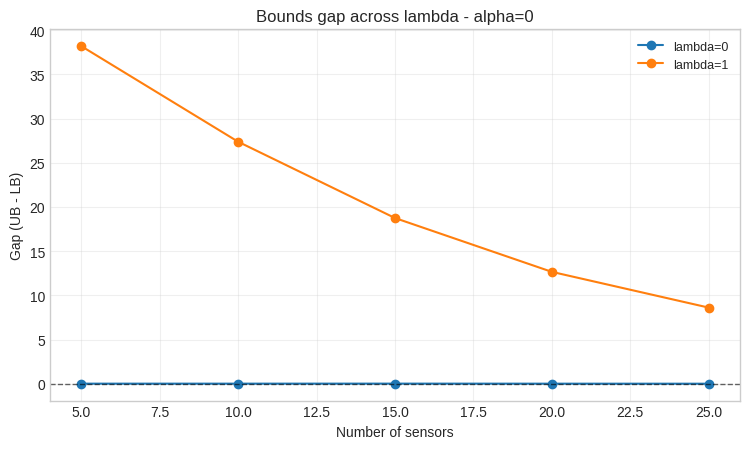

In [10]:
for name, _, mu_slug in mu_configs:
    case = results[name]

    fig_gap, ax_gap = plt.subplots(1, 1, figsize=(7.6, 4.6))
    for lambda_ in lambda_values:
        gap = case["by_lambda"][lambda_]["GAP"]
        ax_gap.plot(sensor_budgets, gap, marker="o", label=f"lambda={lambda_:g}")

    ax_gap.axhline(0.0, color="black", lw=1.0, ls="--", alpha=0.6)
    ax_gap.set_xlabel("Number of sensors")
    ax_gap.set_ylabel("Gap (UB - LB)")
    ax_gap.set_title(f"Bounds gap across lambda - {name}")
    ax_gap.grid(True, alpha=0.3)
    ax_gap.legend(fontsize=9)
    plt.tight_layout()

    out_gap_pdf = output_dir / f"lambda_gap_{mu_slug}.pdf"
    out_gap_png = output_dir / f"lambda_gap_{mu_slug}.png"
    plt.savefig(out_gap_pdf)
    plt.savefig(out_gap_png, dpi=180)
    plt.show()
    plt.close(fig_gap)

    saved_files.extend([str(out_gap_pdf), str(out_gap_png)])


## 7) Cartes de chaleur de `Sigma_Y` et `Sigma_signal`

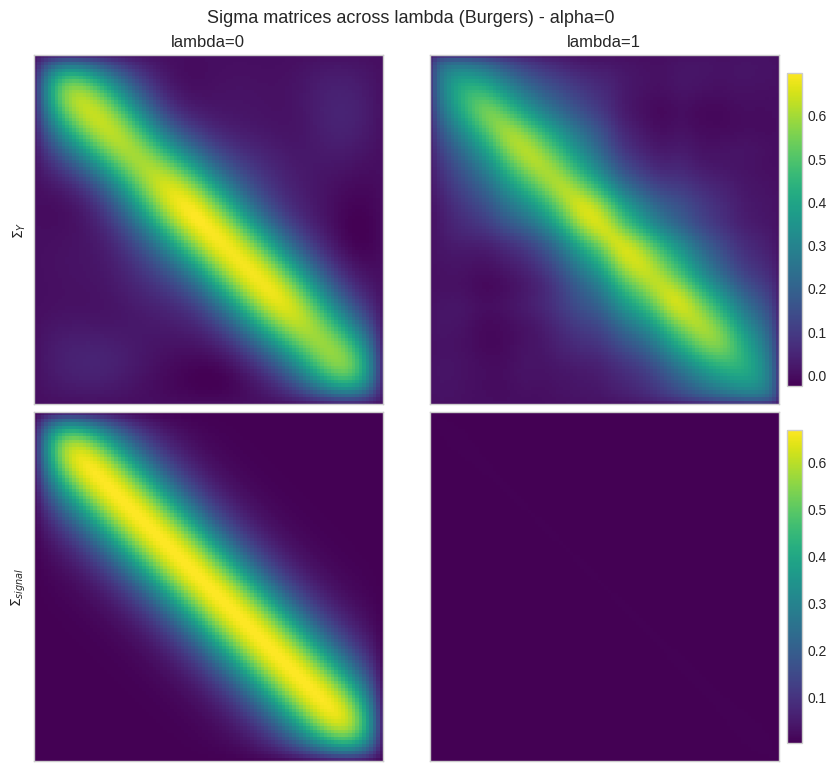

In [11]:
for name, _, mu_slug in mu_configs:
    case = results[name]

    matrix_specs = [
        ("$\\Sigma_Y$", "Sigma_Y"),
        ("$\\Sigma_{signal}$", "Sigma_signal"),
    ]
    n_rows = len(matrix_specs)

    fig_sigma, axes_sigma = plt.subplots(
        n_rows,
        n_lambda,
        figsize=(4.2 * n_lambda, 3.8 * n_rows),
        constrained_layout=True,
    )
    if n_rows == 1:
        axes_sigma = np.array([axes_sigma])
    if n_lambda == 1:
        axes_sigma = axes_sigma.reshape(n_rows, 1)

    for row, (row_label, key) in enumerate(matrix_specs):
        mats = [case["by_lambda"][lam][key] for lam in lambda_values]
        vmin = min(float(m.min()) for m in mats)
        vmax = max(float(m.max()) for m in mats)
        if abs(vmax - vmin) < 1e-15:
            vmax = vmin + 1e-15

        im_row = None
        for col, lambda_ in enumerate(lambda_values):
            ax = axes_sigma[row, col]
            im_row = ax.imshow(mats[col], cmap="viridis", vmin=vmin, vmax=vmax)
            if row == 0:
                ax.set_title(f"lambda={lambda_:g}")
            if col == 0:
                ax.set_ylabel(row_label)
            ax.set_xticks([])
            ax.set_yticks([])

        fig_sigma.colorbar(im_row, ax=axes_sigma[row, :], fraction=0.02, pad=0.01)

    fig_sigma.suptitle(f"Sigma matrices across lambda (Burgers) - {name}", fontsize=13)

    out_sigma_pdf = output_dir / f"lambda_sigmas_{mu_slug}.pdf"
    out_sigma_png = output_dir / f"lambda_sigmas_{mu_slug}.png"
    plt.savefig(out_sigma_pdf)
    plt.savefig(out_sigma_png, dpi=180)
    plt.show()
    plt.close(fig_sigma)

    saved_files.extend([str(out_sigma_pdf), str(out_sigma_png)])


## 8) Contrôle visuel: `u0` vrai vs moyennes `mu_prior`

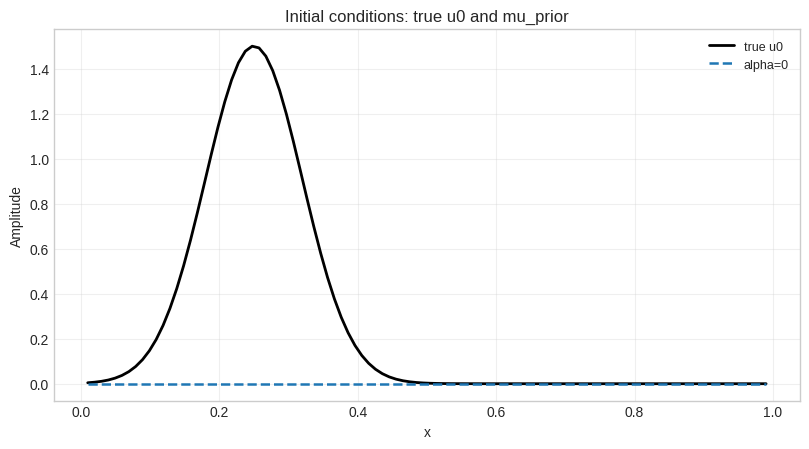


Saved:
  - /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks/boed/results_mu_prior_burgers/lambda_gap_mu0.pdf
  - /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks/boed/results_mu_prior_burgers/lambda_gap_mu0.png
  - /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks/boed/results_mu_prior_burgers/lambda_sigmas_mu0.pdf
  - /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks/boed/results_mu_prior_burgers/lambda_sigmas_mu0.png
  - /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks/boed/results_mu_prior_burgers/mu_prior_profiles.pdf
  - /home/mdoumbou/Documents/Biblio_thèse/pyBOED/tutorials/notebooks/boed/results_mu_prior_burgers/mu_prior_profiles.png


In [12]:
fig_mu, ax_mu = plt.subplots(1, 1, figsize=(8.2, 4.6))
ax_mu.plot(x_grid, u0_true, color="black", lw=2.0, label="true u0")
for name, mu_vec, _ in mu_configs:
    ax_mu.plot(x_grid, mu_vec, lw=1.8, ls="--", label=name)

ax_mu.set_xlabel("x")
ax_mu.set_ylabel("Amplitude")
ax_mu.set_title("Initial conditions: true u0 and mu_prior")
ax_mu.grid(True, alpha=0.3)
ax_mu.legend(fontsize=9)
plt.tight_layout()

out_mu_pdf = output_dir / "mu_prior_profiles.pdf"
out_mu_png = output_dir / "mu_prior_profiles.png"
plt.savefig(out_mu_pdf)
plt.savefig(out_mu_png, dpi=180)
plt.show()
plt.close(fig_mu)

saved_files.extend([str(out_mu_pdf), str(out_mu_png)])

print("\nSaved:")
for path in saved_files:
    print(f"  - {path}")
